# Hybrid LSTM Model for Credit Risk Prediction

This notebook implements a hybrid LSTM model that combines:
- **Sequential features**: Transaction sequences processed by LSTM layers
- **Static features**: User-level aggregated features (loan stats, balances, etc.)

The architecture fuses both inputs using a concatenate layer before the output.

## 1. Setup

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, HybridLSTMModel, ModelEvaluator, set_random_seeds
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

set_random_seeds(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## 2. Data Preparation

In [2]:
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)

static_data = loader.prepare_static_splits()

print(f"Static features: {len(static_data['feature_names'])}")
print(f"Training samples: {len(static_data['y_train'])}")
print(f"Test samples: {len(static_data['y_test'])}")

[DataLoader] Validation passed: 10,000 matching users, label values=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Static features: 40
Training samples: 4761
Test samples: 1191


In [5]:
seq_data = loader.load_sequences(
    max_seq_len=100,
    cache_path=os.path.join(project_root, 'data/lstm_sequences.npz'),
)

print(f"Sequence shape: {seq_data['X_train_seq'].shape}")
print(f"Sequence features: {len(seq_data['feature_names'])}")
print(f"Train default rate: {seq_data['y_train'].mean():.4f}")
print(f"Test default rate: {seq_data['y_test'].mean():.4f}")

Processing 5952 borrower transaction files...
  Processed 1000/5952 users...
  Processed 2000/5952 users...
  Processed 3000/5952 users...
  Processed 4000/5952 users...
  Processed 5000/5952 users...
  Processed 5952/5952 users...
  Train: 4761, Test: 1191
Cached to c:\Users\Dell\Projects\seqcredit-model\data/lstm_sequences.npz
Shapes: train=(4761, 100, 38), test=(1191, 100, 38)
Sequence shape: (4761, 100, 38)
Sequence features: 38
Train default rate: 0.1111
Test default rate: 0.1108


## 3. Prepare Hybrid Data

The hybrid model requires:
- `X_train_seq`, `X_train_static`
- `X_test_seq`, `X_test_static`

We need to align the sequence and static data by user.

In [6]:
from sklearn.preprocessing import StandardScaler

df_features = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))
df = df_features.merge(df_summaries, on='user_id', how='inner')
df = df[df['credit_risk_label'] != -1].copy()
df['default'] = (df['credit_risk_label'] == 2).astype(int)
df = loader._engineer_loan_features(df)

drop_cols = [
    'user_id', 'credit_risk_label', 'credit_archetype', 'default', 'gen_txn_count'
]
feature_cols = [c for c in df.columns if c not in drop_cols]
X_all = df[feature_cols].copy()
y_all = df['default'].copy()
user_ids = df['user_id'].values

static_scaler = StandardScaler()
X_all_scaled = static_scaler.fit_transform(X_all)

# Reuse the same train/test split from loader.prepare_static_splits()
# to ensure the hybrid model is evaluated on the same users as the static models.
train_user_ids = loader._train_user_ids
test_user_ids = loader._test_user_ids

print(f"Total borrowers: {len(user_ids)}")
print(f"Train: {len(train_user_ids)}, Test: {len(test_user_ids)}")

Total borrowers: 5952
Train: 4761, Test: 1191


In [7]:
from seqcredit_model.feature_engineering import TemporalTransactionFeatureEngineer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pathlib import Path

transactions_path = Path(project_root) / 'data' / 'user_transactions'
engineer = TemporalTransactionFeatureEngineer()

def build_hybrid_data(user_id_set, user_to_idx, X_static_all, y_all, user_ids, max_seq_len=100):
    """Build aligned sequence and static data for a set of user IDs."""
    seq_list = []
    static_list = []
    label_list = []
    
    for uid in user_id_set:
        if uid not in user_to_idx:
            continue
        idx = user_to_idx[uid]
        
        filepath = transactions_path / f'{uid}.csv'
        if not filepath.exists():
            continue
        
        try:
            df_user = pd.read_csv(filepath)
            if df_user.empty or len(df_user) < 2:
                continue
            
            df_user['is_loan_disbursement'] = (df_user['TRANS. TYPE'] == 'CREDIT').astype(int)
            df_user['is_loan_repayment'] = (df_user['TRANS. TYPE'] == 'LOAN_REPAYMENT').astype(int)
            
            df_features = engineer.extract_all_features(df_user)
            available_cols = [c for c in seq_data['feature_names'] if c in df_features.columns]
            seq = df_features[available_cols].values.astype(np.float32)
            seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
            
            seq_list.append(seq)
            static_list.append(X_static_all[idx])
            label_list.append(y_all[idx])
        except Exception:
            continue
    
    X_seq = pad_sequences(seq_list, maxlen=max_seq_len, padding='pre', truncating='pre', dtype='float32', value=0.0)
    X_static = np.array(static_list)
    y = np.array(label_list)
    
    return X_seq, X_static, y

user_to_idx = {uid: i for i, uid in enumerate(user_ids)}

print("Building training data...")
X_train_seq, X_train_static, y_train = build_hybrid_data(
    train_user_ids, user_to_idx, X_all_scaled, y_all.values, user_ids
)

print("Building test data...")
X_test_seq, X_test_static, y_test = build_hybrid_data(
    test_user_ids, user_to_idx, X_all_scaled, y_all.values, user_ids
)

print(f"Train: seq {X_train_seq.shape}, static {X_train_static.shape}, y {y_train.shape}")
print(f"Test: seq {X_test_seq.shape}, static {X_test_static.shape}, y {y_test.shape}")

Building training data...
Building test data...
Train: seq (4761, 100, 38), static (4761, 40), y (4761,)
Test: seq (1191, 100, 38), static (1191, 40), y (1191,)


## 4. Model Training

In [8]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes.astype(int), weights))
print(f'Class weights: {class_weights}')

hybrid_model = HybridLSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=16,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
seq_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
static_dim = X_train_static.shape[1]
hybrid_model.build_model(seq_shape, static_dim)
hybrid_model.model.summary()

Class weights: {np.int64(0): np.float64(0.5625), np.int64(1): np.float64(4.5)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 100, 38)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100, 38)   │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 100, 38)   │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 100)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 100, 32)   │      9,088 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 32)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      3,136 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        328 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,969 (50.66 KB)

 Trainable params: 12,969 (50.66 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = hybrid_model.fit(
    X_train_seq, X_train_static, y_train,
    epochs=100, batch_size=32,
    class_weight=class_weights,
)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 181ms/step - auc: 0.5448 - loss: 0.7123 - val_auc: 0.6747 - val_loss: 0.6647 - learning_rate: 5.0000e-04
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - auc: 0.6303 - loss: 0.6637 - val_auc: 0.7425 - val_loss: 0.6190 - learning_rate: 5.0000e-04
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 43s 176ms/step - auc: 0.6935 - loss: 0.6252 - val_auc: 0.7788 - val_loss: 0.5712 - learning_rate: 5.0000e-04
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - auc: 0.7214 - loss: 0.6027 - val_auc: 0.8044 - val_loss: 0.5615 - learning_rate: 5.0000e-04
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - auc: 0.7452 - loss: 0.5805 - val_auc: 0.8207 - val_loss: 0.5496 - learning_rate: 5.0000e-04
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - auc: 0.7835 - loss: 0.5461 - val_auc: 0.8407 - val_loss: 0.5069 - learning_rate: 5.0000e-04
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - auc: 0.8054 - loss: 0.5206 - val_auc: 0.85

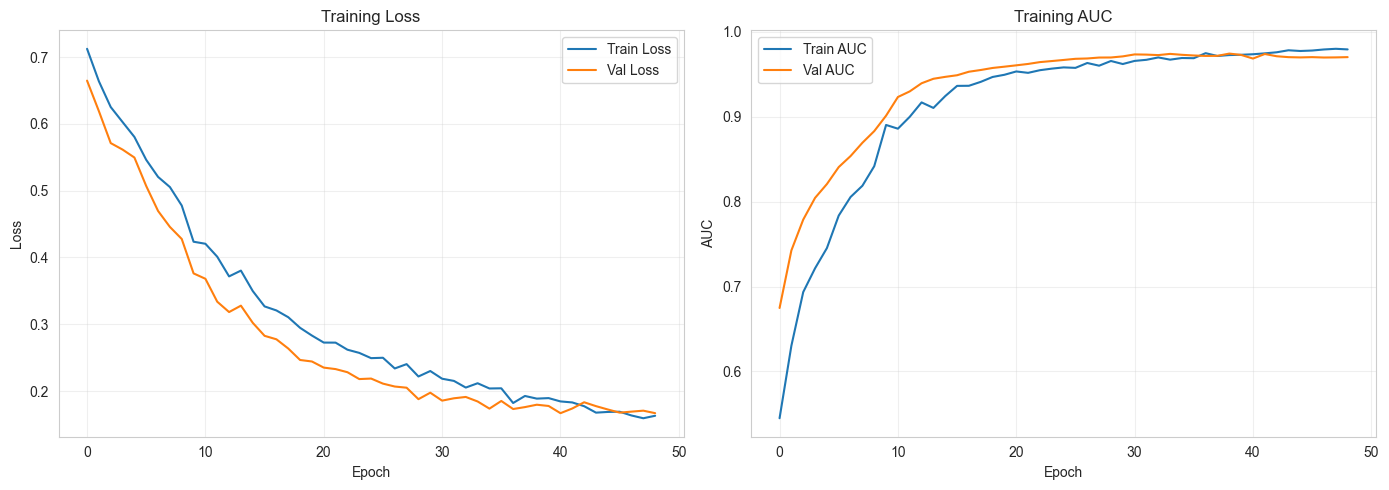

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['auc'], label='Train AUC')
ax2.plot(history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Training AUC')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluation

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

hybrid_proba = hybrid_model.predict_proba(X_test_seq, X_test_static)

print('Hybrid LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(y_test, hybrid_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(y_test, hybrid_proba):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, (hybrid_proba >= 0.5).astype(int), target_names=['Non-Default', 'Default']))

Hybrid LSTM - Test Set Performance:
  AUC-ROC: 0.9598
  AUC-PR: 0.7498

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.99      0.89      0.94      1059
     Default       0.52      0.91      0.66       132

    accuracy                           0.90      1191
   macro avg       0.75      0.90      0.80      1191
weighted avg       0.94      0.90      0.91      1191



## 6. Model Comparison

In [12]:
evaluator = ModelEvaluator(y_test)
evaluator.add_model('Hybrid LSTM', hybrid_proba)

comparison = evaluator.get_comparison_table()
print('\nModel Comparison (Test Set):')
print(comparison.round(4).to_string())


Model Comparison (Test Set):
             AUC-ROC  AUC-PR      F1  Precision  Recall  Accuracy
Model                                                            
Hybrid LSTM   0.9598  0.7498  0.6575      0.515  0.9091     0.895


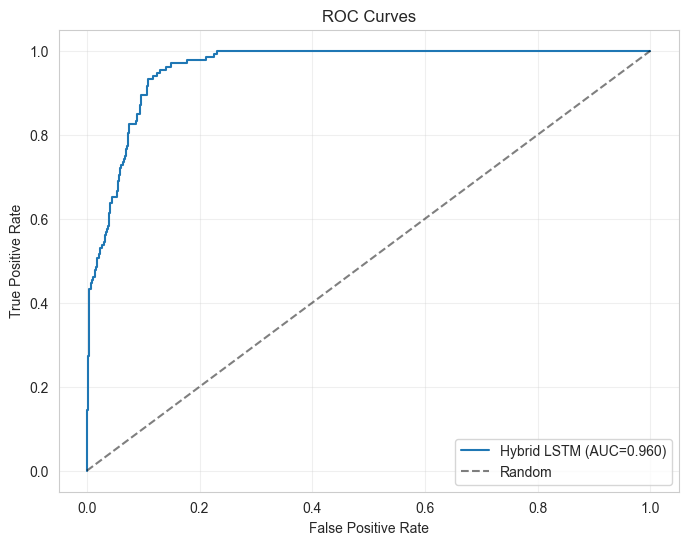

In [13]:
evaluator.plot_roc_curves()
plt.show()

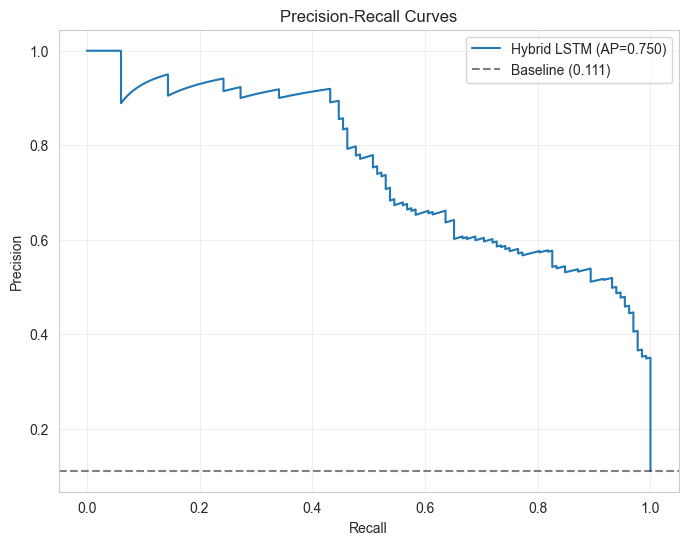

In [14]:
evaluator.plot_pr_curves()
plt.show()

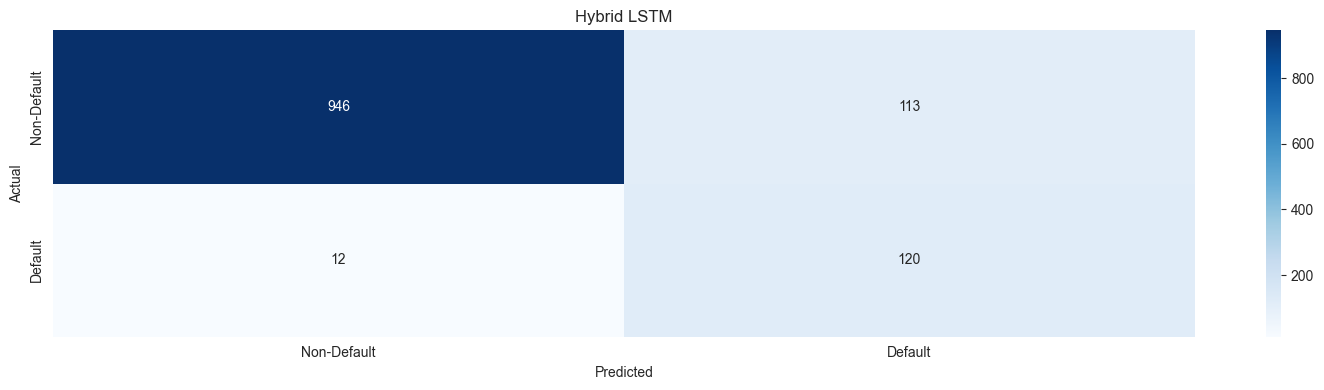

In [15]:
evaluator.plot_confusion_matrices()
plt.show()